In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# In[2]:
# ==========================================
# Step 1: Load Cleaned Features & Filter Active Borrowers
# ==========================================
# Load preprocessed data from data collection stage
cleaned_df = pd.read_csv('01_cleaned_features.csv') 

# Filter criteria: Exclude "zombie accounts" (no credit history/low activity)
# Retain users with non-zero borrow volume and ≥3 transactions
initial_wallet_count = len(cleaned_df)
active_borrowers_df = cleaned_df[(cleaned_df['total_borrow'] > 0) & (cleaned_df['tx_count'] > 3)].copy()
filtered_wallet_count = len(active_borrowers_df)

# Print filtering report (academic transparency)
print(f"Data Cleaning Report:")
print(f"Initial Total Wallets: {initial_wallet_count}")
print(f"Filtered Zombie Accounts (No Credit/Low Activity): {initial_wallet_count - filtered_wallet_count}")
print(f"Valid Active Borrowers for Scoring: {filtered_wallet_count}")

Data Cleaning Report:
Initial Total Wallets: 3497
Filtered Zombie Accounts (No Credit/Low Activity): 2106
Valid Active Borrowers for Scoring: 1391


In [3]:
# In[3]:
# ==========================================
# Step 2: Advanced Feature Engineering for Scoring
# ==========================================
# Log transformation to mitigate skewness (crypto asset distribution bias)
active_borrowers_df['log_total_borrow'] = np.log1p(active_borrowers_df['total_borrow'])
active_borrowers_df['log_total_repay'] = np.log1p(active_borrowers_df['total_repay'])
active_borrowers_df['log_total_deposit'] = np.log1p(active_borrowers_df['total_deposit'])
active_borrowers_df['log_tx_count'] = np.log1p(active_borrowers_df['tx_count'])

# Repayment ratio (clipped to 1.0 to avoid extreme values from over-repayment)
active_borrowers_df['repay_ratio'] = (active_borrowers_df['total_repay'] / (active_borrowers_df['total_borrow'] + 1e-6)).clip(upper=1.0)

# Recency score (higher = more recent transaction activity)
active_borrowers_df['recency_score'] = 1 / (active_borrowers_df['days_since_last_tx'] + 1)

# Coefficient of Variation (CV) for balance volatility (higher = more unstable)
active_borrowers_df['balance_cv'] = active_borrowers_df['balance_std'] / (active_borrowers_df['balance_mean'] + 1e-6)

In [4]:
# In[4]:
# ==========================================
# Step 3: Feature Standardization & Polarity Alignment
# ==========================================
# Select core features for PCA-based scoring
score_features = ['repay_ratio', 'log_total_deposit', 'recency_score', 'balance_cv']
score_feature_matrix = active_borrowers_df[score_features].fillna(0)

# Standardize features (critical for PCA: eliminate scale bias)
standard_scaler = StandardScaler()
scaled_features = pd.DataFrame(standard_scaler.fit_transform(score_feature_matrix), columns=score_features)

# Polarity alignment: Negative CV (higher volatility = lower credit score)
scaled_features['balance_cv'] = scaled_features['balance_cv'] * -1

In [5]:
# In[5]:
# ==========================================
# Step 4: PCA Dimensionality Reduction (1 Component)
# ==========================================
# Initialize PCA (1 component for single credit score)
pca_model = PCA(n_components=1, random_state=42)
raw_pca_scores = pca_model.fit_transform(scaled_features).flatten()

# Critical polarity correction: Ensure higher repay ratio = higher score
repay_score_correlation = np.corrcoef(raw_pca_scores, active_borrowers_df['repay_ratio'])[0, 1]
if repay_score_correlation < 0:
    raw_pca_scores = raw_pca_scores * -1  # Flip if negative correlation

# Assign raw PCA scores to dataframe
active_borrowers_df['pca_raw_score'] = raw_pca_scores

In [6]:
# In[6]:
# ==========================================
# Step 5: Quantile Clipping & Min-Max Scaling (300-850 Range)
# ==========================================
# Clip extreme outliers (1%/99% quantiles) to avoid scale distortion
lower_quantile = active_borrowers_df['pca_raw_score'].quantile(0.01)
upper_quantile = active_borrowers_df['pca_raw_score'].quantile(0.99)
active_borrowers_df['pca_clipped'] = active_borrowers_df['pca_raw_score'].clip(lower_quantile, upper_quantile)

# Scale to traditional credit score range (300 = worst, 850 = best)
min_max_scaler = MinMaxScaler(feature_range=(300, 850))
active_borrowers_df['Scientific_Credit_Score'] = min_max_scaler.fit_transform(active_borrowers_df[['pca_clipped']])

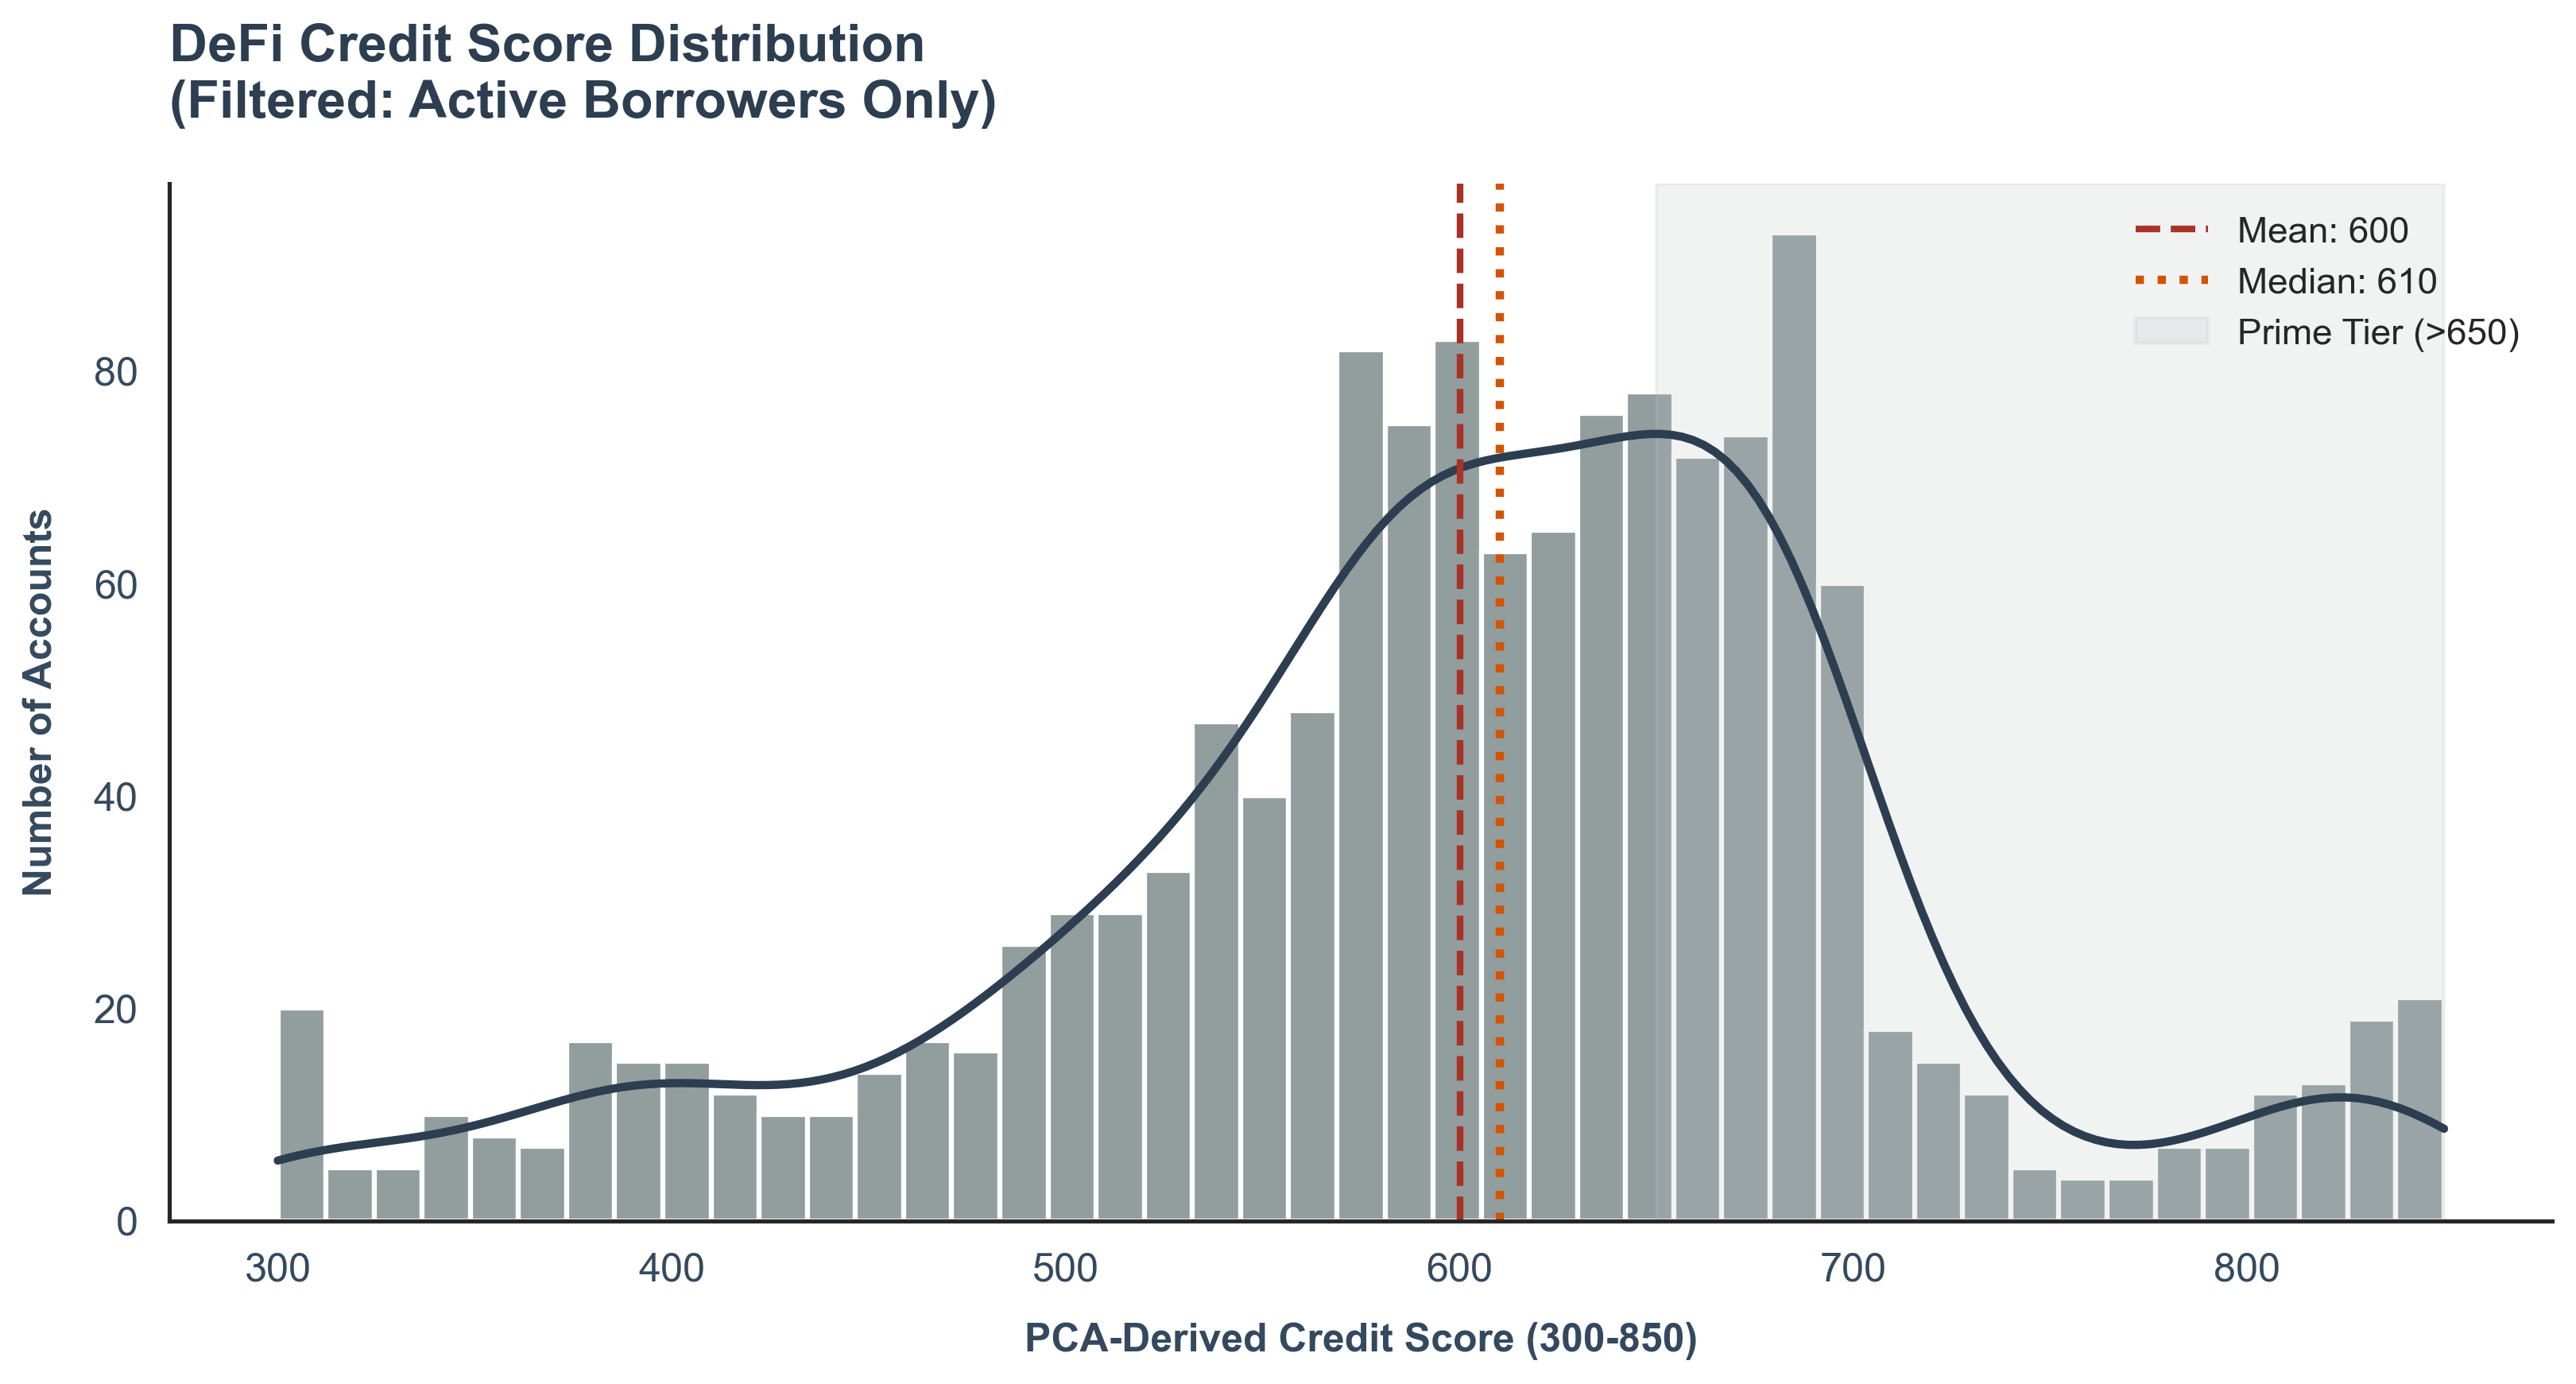

In [7]:
# In[7]:
# ==========================================
# Step 6: Academic Visualization of Score Distribution
# ==========================================
# Set academic plot style (clean, high-resolution, no redundant borders)
plt.figure(figsize=(11, 6), dpi=300)
sns.set_theme(style="white", font_scale=1.1)

# Calculate core statistics for visualization
mean_credit_score = active_borrowers_df['Scientific_Credit_Score'].mean()
median_credit_score = active_borrowers_df['Scientific_Credit_Score'].median()
prime_score_threshold = 650  # Traditional prime credit threshold

# Plot score distribution (histogram + KDE)
ax = sns.histplot(
    active_borrowers_df['Scientific_Credit_Score'], 
    bins=45, 
    kde=True, 
    color='#7F8C8D',         # Slate grey (academic neutral tone)
    edgecolor='white',       # Clean separation between bins
    linewidth=1.5,
    alpha=0.85
)

# Enhance KDE curve (darker color for contrast)
ax.lines[0].set_color('#2C3E50')  # Deep navy
ax.lines[0].set_linewidth(2.5)

# Add labels and title (academic formatting)
plt.ylabel('Number of Accounts', fontsize=12, fontweight='bold', color='#34495E', labelpad=10)
plt.xlabel('PCA-Derived Credit Score (300-850)', fontsize=12, fontweight='bold', color='#34495E', labelpad=10)
plt.title('DeFi Credit Score Distribution\n(Filtered: Active Borrowers Only)', 
          fontsize=16, fontweight='heavy', color='#2C3E50', pad=20, loc='left')

# Add reference lines (mean/median/prime threshold)
plt.axvline(x=mean_credit_score, color='#A93226', linestyle='--', linewidth=2, label=f'Mean: {mean_credit_score:.0f}')
plt.axvline(x=median_credit_score, color='#D35400', linestyle=':', linewidth=2.5, label=f'Median: {median_credit_score:.0f}')
plt.axvspan(prime_score_threshold, 850, color='#BDC3C7', alpha=0.2, label='Prime Tier (>650)')

# Final plot adjustments (academic aesthetics)
sns.despine(left=False, bottom=False)
plt.legend(frameon=False, fontsize=11, loc='upper right')
ax.tick_params(colors='#34495E', which='both')
plt.tight_layout()
plt.show()

In [8]:
# In[8]:
# ==========================================
# Step 7: Save Scored Data for Downstream Risk Analysis
# ==========================================
active_borrowers_df.to_csv('02_scored_users_pca_filtered.csv', index=False)
print("✅ Credit scoring completed. Saved as 02_scored_users_pca_filtered.csv")

✅ Credit scoring completed. Saved as 02_scored_users_pca_filtered.csv
